# National Generalization — Flood Index Analysis, Temporal Evolution, and Impact Assessment for All States of Nigeria (October 2022 Floods)

*Sentinel-1 / Sentinel-2 / CHIRPS / WorldPop / OSM, Google Earth Engine*

`Index_Analysis.ipynb`, `Temporal_Evolution.ipynb` and `Impact_assessment.ipynb` develop and validate a complete flood-analysis methodology — index-based change detection, multi-year anomaly detection, and road/population impact — on a single Region of Interest (ROI) around Lokoja, Kogi State. This notebook asks whether that methodology **generalizes**: does it still work, unchanged, when the region of interest is not a hand-drawn rectangle but all 36 states and the Federal Capital Territory of Nigeria, and does the same flood event look the same everywhere in the country?

It follows the same three-stage structure as the source notebooks, in the order requested — **Index Analysis, Temporal Evolution, Impact Assessment** — reusing their validated ROI-free constants (the pre-flood/flood date windows, the MNDWI > 0 and VH < −19 dB thresholds) verbatim rather than recalibrating them. Earth Engine credentials are authenticated once, in the Index Analysis part below, and reused for the remainder of the notebook. Everything that follows is new relative to the three source notebooks: extending a single-ROI method to a 91-million-hectare country is not just "running the same code on a bigger box," and several sections below exist specifically to show where that naive extension breaks and how this notebook works around it.

# 0. Setup

In [1]:
# pip install earthengine-api geemap statsmodels osmnx networkx geopandas

import ee
import geemap
ee.Authenticate()
ee.Initialize(project='festive-oxide-485716-b0')
print("Earth Engine test :", ee.String("OK").getInfo())

Earth Engine test : OK


Every subsequent part of this notebook (Temporal Evolution, Impact Assessment) reuses this same authenticated `ee` session rather than re-authenticating — the notebook is meant to be run top to bottom in one sitting, unlike the three source notebooks, which are each designed to be independently runnable on their own.

In [2]:
import os

# Same shared output directory as Index_Analysis.ipynb, Temporal_Evolution.ipynb and
# Impact_Assessment.ipynb (Appendix/outputs). Every filename this notebook exports is
# prefixed 'National_' so it cannot collide with those three notebooks' own outputs,
# which already live in this same folder.
OUT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs'))
os.makedirs(OUT_DIR, exist_ok=True)

def save_figure(fig, filename, dpi=300):
    # Save a matplotlib figure to OUT_DIR as a PNG.
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f"[export] Figure -> {path}")
    return path

def save_table(df, filename, index=True):
    # Save a DataFrame to OUT_DIR as a CSV.
    path = os.path.join(OUT_DIR, filename)
    df.to_csv(path, index=index)
    print(f"[export] Table  -> {path}")
    return path

print(f"All figures and tables produced by this notebook will be exported to: {OUT_DIR}")

All figures and tables produced by this notebook will be exported to: /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from collections import Counter
from statsmodels.tsa.seasonal import STL

pd.set_option('display.max_rows', 100)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.3 | numpy 2.3.5


This notebook's longest cells (the 37-state pipeline in Part I, and the per-state loops in Parts II-III) run for tens of minutes with no cell output until they finish. `log_progress` below writes the same message both to the normal cell output and to a plain-text file next to this notebook, so progress can be checked from outside Jupyter (e.g. `tail -f`) while a long cell is still running.

In [4]:
progress_log_path = os.path.join(os.getcwd(), '_national_notebook_progress.log')

def log_progress(message):
    line = f"{datetime.now().strftime('%H:%M:%S')}  {message}"
    print(line)
    with open(progress_log_path, 'a') as f:
        f.write(line + '\n')

with open(progress_log_path, 'w') as f:
    f.write(f"{datetime.now().strftime('%H:%M:%S')}  Progress log started.\n")
print(f"Progress log: {progress_log_path}")

Progress log: /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/notebooks/_national_notebook_progress.log


# PART I --- Index Analysis, Generalized to All States of Nigeria

# 1. Study Framing

## 1.1 Study area: from one ROI to thirty-seven

`Index_Analysis.ipynb` defines its study area as a single rectangle, `ee.Geometry.Rectangle([6.3, 7.4, 7.1, 8.2])`, around Lokoja. The natural generalization is not a bigger rectangle: Nigeria's real administrative geometry is what "all regions of Nigeria" means operationally, so the study area here is the FAO GAUL 2015 level-1 boundary (`FAO/GAUL/2015/level1`) filtered to `ADM0_NAME == 'Nigeria'` -- 36 states plus the Federal Capital Territory (FCT, named `'Abuja'` in this dataset), which together cover essentially all of the country. Local Government Areas (LGAs, GAUL level 2, `FAO/GAUL/2015/level2`) are also loaded here, since Section 5 below reduces every statistic to LGA level directly (this doubles as the administrative layer `Impact_assessment.ipynb` §5.3 uses for its own zonal population statistics).

In [5]:
level1 = ee.FeatureCollection('FAO/GAUL/2015/level1')
level2 = ee.FeatureCollection('FAO/GAUL/2015/level2')

nga_states = level1.filter(ee.Filter.eq('ADM0_NAME', 'Nigeria'))
nga_lgas = level2.filter(ee.Filter.eq('ADM0_NAME', 'Nigeria'))
nga_boundary = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Nigeria'))
nga_geom = nga_boundary.geometry()

state_names = sorted(nga_states.aggregate_array('ADM1_NAME').getInfo())
n_lgas = nga_lgas.size().getInfo()
nga_area_ha = nga_geom.area(1).divide(10000).getInfo()

print(f"Nigeria: {len(state_names)} states/territories, {n_lgas} LGAs, "
      f"{nga_area_ha:,.0f} ha total area (~{nga_area_ha / 785_759:.0f}x the Lokoja ROI in Index_Analysis.ipynb).")
print(state_names)

Nigeria: 37 states/territories, 775 LGAs, 91,270,212 ha total area (~116x the Lokoja ROI in Index_Analysis.ipynb).
['Abia', 'Abuja', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi', 'Bayelsa', 'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi', 'Edo', 'Ekiti', 'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nassarawa', 'Niger', 'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto', 'Taraba', 'Yobe', 'Zamfara']


In [6]:
Map = geemap.Map(center=[9.1, 8.7], zoom=6)
Map.addLayer(nga_states.style(color='#d7263d', fillColor='00000000', width=1.5), {}, 'Nigeria states (ADM1)')
Map.addLayer(nga_boundary.style(color='black', fillColor='00000000', width=2), {}, 'National boundary')
Map

Map(center=[9.1, 8.7], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

## 1.2 Event window

Reused, unchanged, from `Index_Analysis.ipynb`: pre-flood (July-August 2022) and flood (late September-October 2022). These dates were validated there against one location; Section 13 below revisits whether a single national window is appropriate for a country-scale flood that, per NEMA and OCHA situation reports, peaked at different times in different basins (the Niger-Benue confluence states in early-mid October, parts of the Niger Delta later into November).

In [7]:
# Same event windows as Index_Analysis.ipynb -- reused verbatim, not recalibrated
pre_flood_start = '2022-07-01'
pre_flood_end   = '2022-08-31'

flood_start = '2022-09-25'
flood_end   = '2022-10-31'

# 2. Data Sources

| Source | Role | Resolution | Notes |
|---|---|---|---|
| Sentinel-2 SR Harmonized (`COPERNICUS/S2_SR_HARMONIZED`) | Optical water index (MNDWI) | 10-20 m | Cloud-masked with Cloud Score+, same 0.6 threshold as `Index_Analysis.ipynb` |
| Cloud Score+ (`GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED`) | Per-pixel clear-sky probability | 10 m | `cs_cdf >= 0.6` |
| Sentinel-1 GRD (`COPERNICUS/S1_GRD`) | All-weather SAR water detection (VH) | 10 m | IW mode; orbit pass selected per state (Section 5.1) |
| WorldPop (`WorldPop/GP/100m/pop`, 2020) | Population exposure | ~100 m | Same vintage as `Impact_assessment.ipynb` |
| CHIRPS v3 Pentad (`UCSB-CHC/CHIRPS/V3/PENTAD`) | National precipitation context | ~5.5 km | Same collection as `Temporal_Evolution.ipynb` |
| FAO GAUL 2015 level 1 / level 2 | States and LGAs | vector | 2015 |

## 3. Methodology Recap (Thresholds Reused Verbatim)

`Index_Analysis.ipynb` calibrates and statistically validates two flood-detection thresholds for the Lokoja ROI: **MNDWI (B3, B11) > 0** for Sentinel-2, and **VH < -19 dB** (after a 50 m focal-median speckle filter) for Sentinel-1. Both are reused here exactly as they are, for every state -- this notebook tests whether they *generalize* spatially, so changing them per region would defeat the point. Section 13 comes back to what it means when a state's results suggest they do not transfer well.

In [8]:
cs_plus = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED')
CLEAR_THRESHOLD = 0.6

def mask_clouds_csplus(image):
    return image.updateMask(image.select('cs_cdf').gte(CLEAR_THRESHOLD))

MNDWI_THRESHOLD = 0
VH_THRESHOLD = -19
SPECKLE_RADIUS_M = 50

population = ee.ImageCollection('WorldPop/GP/100m/pop').filter(ee.Filter.eq('year', 2020)).mosaic()
pop_band = population.bandNames().get(0).getInfo()
print(f"MNDWI > {MNDWI_THRESHOLD}, VH < {VH_THRESHOLD} dB, WorldPop band = '{pop_band}' -- all reused from "
      "Index_Analysis.ipynb / Impact_assessment.ipynb without modification.")

MNDWI > 0, VH < -19 dB, WorldPop band = 'population' -- all reused from Index_Analysis.ipynb / Impact_assessment.ipynb without modification.


# 4. Why a Per-State Decomposition Is Required at National Scale

The direct generalization of `Index_Analysis.ipynb` would clip the same pre-flood/flood MNDWI and VH computation to `nga_geom` instead of `roi`, and reduce it once over all 37 states with a single `reduceRegions` call. The cell below runs exactly that, at a resolution (250 m) already coarser than anything else in this notebook, with `tileScale=4` to reduce memory pressure -- and is expected to fail. This is not a strawman: it is the literal generalization a reader would try first, and its failure is the empirical justification (not just an assertion) for every architectural choice in Section 5.

In [9]:
# Deliberately naive nationwide attempt -- expected to raise EEException: Computation
# timed out after Earth Engine's ~300s interactive compute budget. Wrapped in try/except
# so the notebook keeps running; the failure itself is the result of this cell.
s2_linked_demo = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(nga_geom)
                  .linkCollection(cs_plus.filterBounds(nga_geom), ['cs_cdf']))
flood_img_demo = s2_linked_demo.filterDate(flood_start, flood_end).map(mask_clouds_csplus).median().clip(nga_geom)
pre_img_demo = s2_linked_demo.filterDate(pre_flood_start, pre_flood_end).map(mask_clouds_csplus).median().clip(nga_geom)
mndwi_flood_demo = flood_img_demo.normalizedDifference(['B3', 'B11'])
mndwi_pre_demo = pre_img_demo.normalizedDifference(['B3', 'B11'])
flood_mask_demo = mndwi_flood_demo.gt(MNDWI_THRESHOLD).subtract(mndwi_pre_demo.gt(MNDWI_THRESHOLD)).gt(0)
area_demo = flood_mask_demo.rename('ha').multiply(ee.Image.pixelArea()).divide(10000)

t0 = time.time()
try:
    result = area_demo.reduceRegions(collection=nga_states, reducer=ee.Reducer.sum(), scale=250, tileScale=4).getInfo()
    print(f"Unexpectedly succeeded in {time.time()-t0:.1f}s -- {len(result['features'])} states returned.")
except ee.EEException as exc:
    print(f"Failed after {time.time()-t0:.1f}s, as expected: {type(exc).__name__}: {exc}")
    print("This is exactly why Section 5 processes one state at a time instead.")

Failed after 299.8s, as expected: EEException: Computation timed out.
This is exactly why Section 5 processes one state at a time instead.


# 5. National Per-State Processing Pipeline

## 5.1 Design

Each state is processed independently, reproducing `Index_Analysis.ipynb`'s Sentinel-2/Sentinel-1 flood masks and `Impact_assessment.ipynb`'s fused mask and population overlay on that state's own geometry alone, then reduced in **one combined `reduceRegions` call per state** against that state's LGAs -- five bands (`s2_ha`, `s1_ha`, `fused_ha`, `population`, `pop_affected`) reduced together, rather than five separate calls, so the expensive part (building the cloud-masked composites) is paid for once per state rather than once per statistic. This is what Section 6 (flood extent) and Section 25 (population exposure) both draw on; population exposure is computed here rather than recomputed in the Impact Assessment part, since -- unlike the three source notebooks, which are each designed to run independently -- this is one notebook and re-deriving the same composites a second time would silently double the runtime for no benefit.

The Sentinel-1 orbit pass is selected **per state**, not once nationally. `Temporal_Evolution.ipynb` §3.1 found a single dominant pass for Lokoja alone (ASCENDING, 7.3 vs 0.1 acquisitions/month) and used that finding to fix one pass for its whole series. A wider check across 11 states spanning the country (done while developing this notebook) shows that does not generalize: Kano, Sokoto and Niger are ASCENDING-only in the 2022 windows used here, while Rivers, Bayelsa, Cross River, Adamawa and Taraba have substantial coverage from *both* passes. `Impact_assessment.ipynb` §3.1's per-case selection (pick whichever pass both periods share) is therefore applied independently for every state below, not simplified to a single national constant.

Every reduction uses `scale=100` (matching the coarser scale `Index_Analysis.ipynb` itself switches to for its climatology sections, rather than the `scale=30` used there for the single-ROI hectare totals) -- a necessary resolution tradeoff at 91-million-hectare scale, revisited in Section 13.

In [10]:
def process_state(state_name, state_geom, state_lgas, scale=100):
    """Reproduce Index_Analysis.ipynb's S2/S1 flood masks and Impact_assessment.ipynb's
    fused mask + population overlay for a single state, reduced once over its LGAs.
    Returns (rows, masks_dict, elapsed_seconds)."""
    t0 = time.time()

    # --- Sentinel-2 / MNDWI ---
    s2_linked = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(state_geom)
                 .linkCollection(cs_plus.filterBounds(state_geom), ['cs_cdf']))
    pre_img = s2_linked.filterDate(pre_flood_start, pre_flood_end).map(mask_clouds_csplus).median().clip(state_geom)
    flood_img = s2_linked.filterDate(flood_start, flood_end).map(mask_clouds_csplus).median().clip(state_geom)
    mndwi_pre = pre_img.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    mndwi_flood = flood_img.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    s2_mask = mndwi_flood.gt(MNDWI_THRESHOLD).subtract(mndwi_pre.gt(MNDWI_THRESHOLD)).gt(0).rename('s2_flood')

    # --- Sentinel-1 / VH, orbit pass chosen per state (Section 5.1) ---
    s1_all = (ee.ImageCollection('COPERNICUS/S1_GRD').filterBounds(state_geom)
              .filter(ee.Filter.eq('instrumentMode', 'IW'))
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')))
    passes_pre = Counter(s1_all.filterDate(pre_flood_start, pre_flood_end).aggregate_array('orbitProperties_pass').getInfo())
    passes_flood = Counter(s1_all.filterDate(flood_start, flood_end).aggregate_array('orbitProperties_pass').getInfo())
    common = set(passes_pre) & set(passes_flood)
    orbit_pass = max(common, key=lambda p: passes_pre[p] + passes_flood[p]) if common else None

    if orbit_pass is not None:
        s1_col = s1_all.filter(ee.Filter.eq('orbitProperties_pass', orbit_pass)).select('VH')
        s1_pre = s1_col.filterDate(pre_flood_start, pre_flood_end).median().focal_median(SPECKLE_RADIUS_M, 'circle', 'meters').clip(state_geom)
        s1_flood = s1_col.filterDate(flood_start, flood_end).median().focal_median(SPECKLE_RADIUS_M, 'circle', 'meters').clip(state_geom)
        s1_mask = s1_flood.lt(VH_THRESHOLD).subtract(s1_pre.lt(VH_THRESHOLD)).gt(0).rename('s1_flood')
    else:
        s1_pre = s1_flood = None
        s1_mask = ee.Image.constant(0).updateMask(ee.Image.constant(0)).rename('s1_flood')

    # --- Fused mask (Impact_assessment.ipynb Section 3.1: unmask(0) before Or()) ---
    fused_mask = s2_mask.unmask(0).Or(s1_mask.unmask(0)).rename('fused_flood')
    pop_affected = population.updateMask(fused_mask).rename('pop_affected')

    ha = ee.Image.pixelArea().divide(10000)
    combined = (s2_mask.multiply(ha).rename('s2_ha')
                .addBands(s1_mask.multiply(ha).rename('s1_ha'))
                .addBands(fused_mask.multiply(ha).rename('fused_ha'))
                .addBands(population.rename('population'))
                .addBands(pop_affected))

    stats_fc = combined.reduceRegions(collection=state_lgas, reducer=ee.Reducer.sum(),
                                       scale=scale, tileScale=4, maxPixelsPerRegion=1e10)
    feats = stats_fc.getInfo()['features']

    rows = []
    for f in feats:
        p = f['properties']
        rows.append({
            'ADM1_NAME': state_name,
            'ADM2_NAME': p.get('ADM2_NAME'),
            's2_ha': p.get('s2_ha') or 0,
            's1_ha': (np.nan if orbit_pass is None else (p.get('s1_ha') or 0)),
            'fused_ha': p.get('fused_ha') or 0,
            'population': p.get('population') or 0,
            'pop_affected': p.get('pop_affected') or 0,
        })

    masks = {
        'geom': state_geom, 'orbit_pass': orbit_pass,
        'mndwi_pre': mndwi_pre, 'mndwi_flood': mndwi_flood,
        's1_pre': s1_pre, 's1_flood': s1_flood,
        's2_mask': s2_mask, 's1_mask': s1_mask, 'fused_mask': fused_mask,
    }
    return rows, masks, time.time() - t0

## 5.2 Running the pipeline over all 37 states/territories

This is the single most expensive cell in the notebook: each state independently rebuilds and reduces its own cloud-masked Sentinel-2 composites and speckle-filtered Sentinel-1 composites, so the total runtime scales with the number of states, not with the size of any one of them. Based on timing samples taken while developing this notebook (a small state like Lagos in well under a minute, a large or cloud-heavy state like Kogi over two minutes), the full loop is expected to take on the order of **45-75 minutes**. Each state is wrapped in its own `try/except` so that a single failure does not discard the progress already made on the other 36.

In [11]:
all_rows = []
state_masks = {}
failed_states = []
no_common_pass_states = []
loop_t0 = time.time()

for i, name in enumerate(state_names, 1):
    geom = nga_states.filter(ee.Filter.eq('ADM1_NAME', name)).geometry()
    lgas = nga_lgas.filter(ee.Filter.eq('ADM1_NAME', name))
    try:
        rows, masks, elapsed = process_state(name, geom, lgas)
        all_rows.extend(rows)
        state_masks[name] = masks
        flag = f"orbit={masks['orbit_pass']}" if masks['orbit_pass'] else "NO COMMON S1 ORBIT PASS"
        if masks['orbit_pass'] is None:
            no_common_pass_states.append(name)
        log_progress(f"[{i:2d}/{len(state_names)}] {name:15s} {len(rows):3d} LGAs  {elapsed:6.1f}s  {flag}")
    except Exception as exc:
        failed_states.append((name, f"{type(exc).__name__}: {exc}"))
        log_progress(f"[{i:2d}/{len(state_names)}] {name:15s} FAILED -- {type(exc).__name__}: {exc}")

total_minutes = (time.time() - loop_t0) / 60
log_progress(f"Pipeline finished in {total_minutes:.1f} minutes. "
             f"{len(failed_states)} state(s) failed outright, {len(no_common_pass_states)} had no shared S1 orbit pass.")
if failed_states:
    print("Failed states:", failed_states)
if no_common_pass_states:
    print("No common S1 orbit pass:", no_common_pass_states)

04:47:01  [ 1/37] Abia             17 LGAs    34.2s  orbit=DESCENDING


04:47:20  [ 2/37] Abuja             6 LGAs    19.3s  orbit=ASCENDING


04:48:12  [ 3/37] Adamawa          21 LGAs    51.9s  orbit=ASCENDING


04:48:26  [ 4/37] Akwa Ibom        31 LGAs    13.8s  orbit=DESCENDING


04:48:37  [ 5/37] Anambra          21 LGAs    10.9s  orbit=DESCENDING


...

05:09:46  [33/37] Rivers           23 LGAs    34.9s  orbit=DESCENDING


05:10:08  [34/37] Sokoto           23 LGAs    22.1s  orbit=ASCENDING


05:10:32  [35/37] Taraba           16 LGAs    24.7s  orbit=ASCENDING


05:11:38  [36/37] Yobe             17 LGAs    65.8s  orbit=ASCENDING


05:12:31  [37/37] Zamfara          14 LGAs    52.9s  orbit=ASCENDING
05:12:31  Pipeline finished in 26.1 minutes. 0 state(s) failed outright, 0 had no shared S1 orbit pass.


In [12]:
df_lga = pd.DataFrame(all_rows)
save_table(df_lga, 'National_Flood_And_Population_By_LGA.csv', index=False)

df_state = (df_lga.groupby('ADM1_NAME')[['s2_ha', 's1_ha', 'fused_ha', 'population', 'pop_affected']]
            .sum(min_count=1).reset_index())
df_state = df_state.sort_values('fused_ha', ascending=False).reset_index(drop=True)
save_table(df_state, 'National_Flood_Extent_By_State.csv', index=False)

print(f"{len(df_lga)} LGA-level rows, {len(df_state)} state-level rows.")
df_state.head(10)

[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_Flood_And_Population_By_LGA.csv
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_Flood_Extent_By_State.csv
775 LGA-level rows, 37 state-level rows.


,ADM1_NAME,s2_ha,s1_ha,fused_ha,population,pop_affected
0,Borno,16368.585914,410797.688681,424362.485641,5.760658e+06,299298.019468
1,Yobe,63146.091481,342999.184356,383515.640031,3.204226e+06,309451.246311
2,Sokoto,8098.052022,322323.256337,327680.885148,4.884098e+06,341804.037422
3,Taraba,164363.719111,223579.150527,289188.763756,2.918794e+06,158812.348365
4,Niger,186560.878729,149985.065362,233480.879219,5.378856e+06,188230.897458
5,Kogi,173295.698896,108464.253924,194618.932906,4.278480e+06,331752.797321
6,Kebbi,66748.468664,131497.192606,172607.733357,4.271810e+06,178575.220793
7,Bauchi,9247.536279,149376.576070,154607.062275,6.257442e+06,243825.203072
8,Delta,111756.910103,63994.557370,141452.761769,5.440825e+06,397619.801894
9,Jigawa,61629.314115,99847.396032,137682.401968,5.542275e+06,339179.975959


# 6. National Flood-Extent Results

Following `Index_Analysis.ipynb`'s own comparison table (Sentinel-2 vs. Sentinel-1 vs. their union), but now with one row per state instead of one row for the whole ROI, ranked by the fused (S1 OR S2) net-new flooded area.

In [13]:
display_cols = ['ADM1_NAME', 's2_ha', 's1_ha', 'fused_ha']
fmt_state = df_state[display_cols].copy()
for c in ['s2_ha', 's1_ha', 'fused_ha']:
    fmt_state[c] = fmt_state[c].round(1)

print(f"National total (sum of all {len(df_state)} states) -- "
      f"S2 MNDWI: {df_state['s2_ha'].sum():,.0f} ha | "
      f"S1 VH: {df_state['s1_ha'].sum(skipna=True):,.0f} ha | "
      f"Fused: {df_state['fused_ha'].sum():,.0f} ha "
      f"({df_state['fused_ha'].sum() / nga_area_ha * 100:.2f}% of Nigeria's land area)")
fmt_state.head(15)

National total (sum of all 37 states) -- S2 MNDWI: 1,262,562 ha | S1 VH: 2,587,690 ha | Fused: 3,260,064 ha (3.57% of Nigeria's land area)


,ADM1_NAME,s2_ha,s1_ha,fused_ha
0,Borno,16368.6,410797.7,424362.5
1,Yobe,63146.1,342999.2,383515.6
2,Sokoto,8098.1,322323.3,327680.9
3,Taraba,164363.7,223579.2,289188.8
4,Niger,186560.9,149985.1,233480.9
5,Kogi,173295.7,108464.3,194618.9
6,Kebbi,66748.5,131497.2,172607.7
7,Bauchi,9247.5,149376.6,154607.1
8,Delta,111756.9,63994.6,141452.8
9,Jigawa,61629.3,99847.4,137682.4


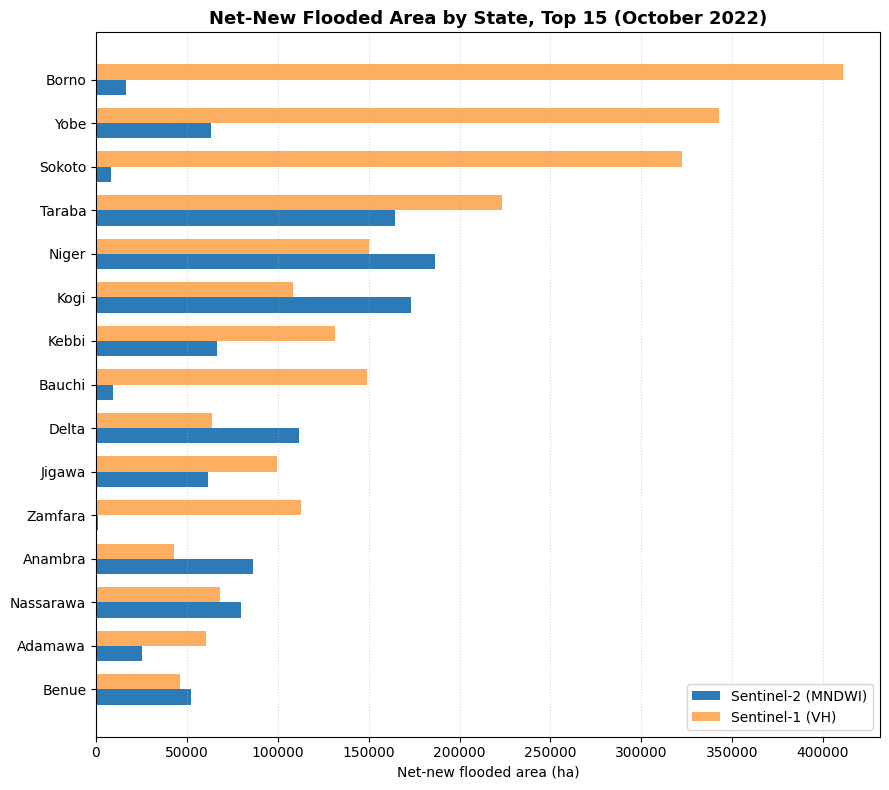

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_Flood_Extent_Top15_States.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_Flood_Extent_Top15_States.png'

In [14]:
top15 = df_state.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
width = 0.35
y = np.arange(len(top15))
ax.barh(y - width/2, top15['s2_ha'], width, label='Sentinel-2 (MNDWI)', color='#2c7bb6')
ax.barh(y + width/2, top15['s1_ha'], width, label='Sentinel-1 (VH)', color='#fdae61')
ax.set_yticks(y)
ax.set_yticklabels(top15['ADM1_NAME'])
ax.set_xlabel('Net-new flooded area (ha)')
ax.set_title('Net-New Flooded Area by State, Top 15 (October 2022)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

save_figure(fig, 'National_Flood_Extent_Top15_States.png')

# 7. Cross-Sensor Agreement Diagnostic

`Index_Analysis.ipynb` cross-checks Sentinel-1 against Sentinel-2 for one ROI and finds broadly comparable orders of magnitude (53,650.96 ha vs. 38,411.59 ha). At national scale, with the same two fixed thresholds applied to 37 different landscapes, agreement is not guaranteed to hold everywhere -- a state where the two sensors disagree by an order of magnitude is a sign that the thresholds are not transferring well to that state's terrain or land cover, not that one sensor "found more flooding" than the other.

In [15]:
df_ratio = df_state[df_state['s1_ha'].notna() & (df_state['s2_ha'] > 0)].copy()
df_ratio['s1_s2_ratio'] = df_ratio['s1_ha'] / df_ratio['s2_ha']
df_ratio = df_ratio.sort_values('s1_s2_ratio', ascending=False)

outliers = df_ratio[(df_ratio['s1_s2_ratio'] > 5) | (df_ratio['s1_s2_ratio'] < 0.2)]
print(f"{len(outliers)} of {len(df_ratio)} states show S1/S2 ratio outside [0.2x, 5x] "
      "-- candidates for threshold-transfer failure rather than genuine cross-sensor disagreement:")
display_ratio = df_ratio[['ADM1_NAME', 's2_ha', 's1_ha', 's1_s2_ratio']].round(2)
save_table(display_ratio, 'National_Cross_Sensor_Agreement_Ratio.csv', index=False)
display_ratio.head(10)

12 of 37 states show S1/S2 ratio outside [0.2x, 5x] -- candidates for threshold-transfer failure rather than genuine cross-sensor disagreement:
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_Cross_Sensor_Agreement_Ratio.csv


,ADM1_NAME,s2_ha,s1_ha,s1_s2_ratio
10,Zamfara,1302.37,112817.81,86.62
2,Sokoto,8098.05,322323.26,39.80
17,Katsina,1031.98,36924.58,35.78
0,Borno,16368.59,410797.69,25.10
7,Bauchi,9247.54,149376.58,16.15
16,Gombe,4873.81,41357.35,8.49
22,Plateau,2595.65,21572.02,8.31
36,Ekiti,34.46,277.81,8.06
1,Yobe,63146.09,342999.18,5.43
26,Oyo,1191.75,6409.76,5.38


**Reading the outliers.** A ratio far from 1 in either direction usually does not mean "no flooding happened here" -- it means the two sensors' physical mechanisms respond differently to whatever *is* on the ground. VH < -19 dB flags any smooth, specular-reflecting surface, which genuine floodwater produces but so can dry lakebeds, sand sheets, or harmattan-dust-flattened terrain in the semi-arid north; MNDWI > 0 depends on Sentinel-2 actually acquiring a cloud-free scene, which is the sensor's own weak point in the cloudier south (`Index_Analysis.ipynb`'s own observability study). A state with S1 far above S2 is a candidate for SAR false positives over non-water smooth surfaces; a state with S2 far above S1 is a candidate for a cloud-starved optical composite. Section 12 below returns to this same optical/SAR tradeoff regionally with the cloud-observability comparison; neither threshold is retuned here per state, since doing so would defeat the purpose of testing whether Lokoja's calibration generalizes.

# 8. Cross-Check Against the Validated Lokoja/Kogi Baseline

Kogi State contains the entire Lokoja ROI, so its own net-new flooded area from the pipeline above should be *at least* `Index_Analysis.ipynb`'s validated ROI-only figures, not smaller than them and not wildly larger given the ROI already covers the Niger-Benue confluence itself.

In [16]:
lokoja_s2_ha, lokoja_s1_ha = 53_650.96, 38_411.59  # Index_Analysis.ipynb, validated ROI-only figures

kogi_row = df_state[df_state['ADM1_NAME'] == 'Kogi'].iloc[0]
print(f"Index_Analysis.ipynb (Lokoja ROI only):  S2 = {lokoja_s2_ha:>12,.2f} ha | S1 = {lokoja_s1_ha:>12,.2f} ha")
print(f"This notebook (all of Kogi State):       S2 = {kogi_row['s2_ha']:>12,.2f} ha | S1 = {kogi_row['s1_ha']:>12,.2f} ha")

for label, lokoja_val, kogi_val in [('S2', lokoja_s2_ha, kogi_row['s2_ha']), ('S1', lokoja_s1_ha, kogi_row['s1_ha'])]:
    status = "consistent (Kogi >= ROI, same order of magnitude)" if kogi_val >= lokoja_val else "INCONSISTENT -- investigate"
    print(f"  {label}: {status}")

Index_Analysis.ipynb (Lokoja ROI only):  S2 =    53,650.96 ha | S1 =    38,411.59 ha
This notebook (all of Kogi State):       S2 =   173,295.70 ha | S1 =   108,464.25 ha
  S2: consistent (Kogi >= ROI, same order of magnitude)
  S1: consistent (Kogi >= ROI, same order of magnitude)


# 9. Nationwide Precipitation Context (CHIRPS)

A genuinely nationwide product, and a cheap one: unlike the flood masks above, CHIRPS is a pre-gridded ~5.5 km raster, so the 22-year climatological mean can be collapsed to a single image with one server-side `.mean()` over the yearly composites *before* the per-state reduction, rather than repeating the per-state reduction once per year -- the same "collapse the expensive dimension first" principle Section 5 applies to the flood masks, applied here to time instead of to states.

In [17]:
chirps = ee.ImageCollection('UCSB-CHC/CHIRPS/V3/PENTAD').select('precipitation')

clim_years = list(range(2000, 2022))
yearly_sept_oct_sums = [chirps.filterDate(f'{y}-09-01', f'{y}-11-01').sum() for y in clim_years]
chirps_climatology_img = ee.ImageCollection(yearly_sept_oct_sums).mean().rename('clim_mean')
chirps_2022_img = chirps.filterDate('2022-09-01', '2022-11-01').sum().rename('actual_2022')

precip_combined = chirps_climatology_img.addBands(chirps_2022_img)
precip_by_state = precip_combined.reduceRegions(collection=nga_states, reducer=ee.Reducer.mean(), scale=5566, tileScale=4)

precip_feats = precip_by_state.getInfo()['features']
df_precip = pd.DataFrame([{
    'ADM1_NAME': f['properties']['ADM1_NAME'],
    'clim_mean_mm': f['properties'].get('clim_mean'),
    'actual_2022_mm': f['properties'].get('actual_2022'),
} for f in precip_feats])
df_precip['anomaly_mm'] = df_precip['actual_2022_mm'] - df_precip['clim_mean_mm']
df_precip['anomaly_pct'] = (df_precip['anomaly_mm'] / df_precip['clim_mean_mm'] * 100).round(1)
df_precip = df_precip.sort_values('anomaly_mm', ascending=False).reset_index(drop=True)

save_table(df_precip, 'National_CHIRPS_SeptOct_Anomaly_By_State.csv', index=False)
print(f"CHIRPS Sept-Oct 2022 rainfall anomaly vs. {len(clim_years)}-year (2000-2021) climatology, by state:")
df_precip.round(1).head(10)

[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_CHIRPS_SeptOct_Anomaly_By_State.csv
CHIRPS Sept-Oct 2022 rainfall anomaly vs. 22-year (2000-2021) climatology, by state:


,ADM1_NAME,clim_mean_mm,actual_2022_mm,anomaly_mm,anomaly_pct
0,Kano,206.9,299.4,92.5,44.7
1,Jigawa,115.0,205.8,90.8,79.0
2,Kebbi,229.9,301.5,71.6,31.2
3,Katsina,165.7,234.9,69.1,41.7
4,Bauchi,245.5,310.4,64.9,26.4
5,Sokoto,128.8,181.0,52.2,40.6
6,Borno,161.7,210.9,49.3,30.5
7,Oyo,388.7,436.3,47.6,12.2
8,Lagos,436.2,480.5,44.3,10.2
9,Ogun,425.1,464.8,39.7,9.3


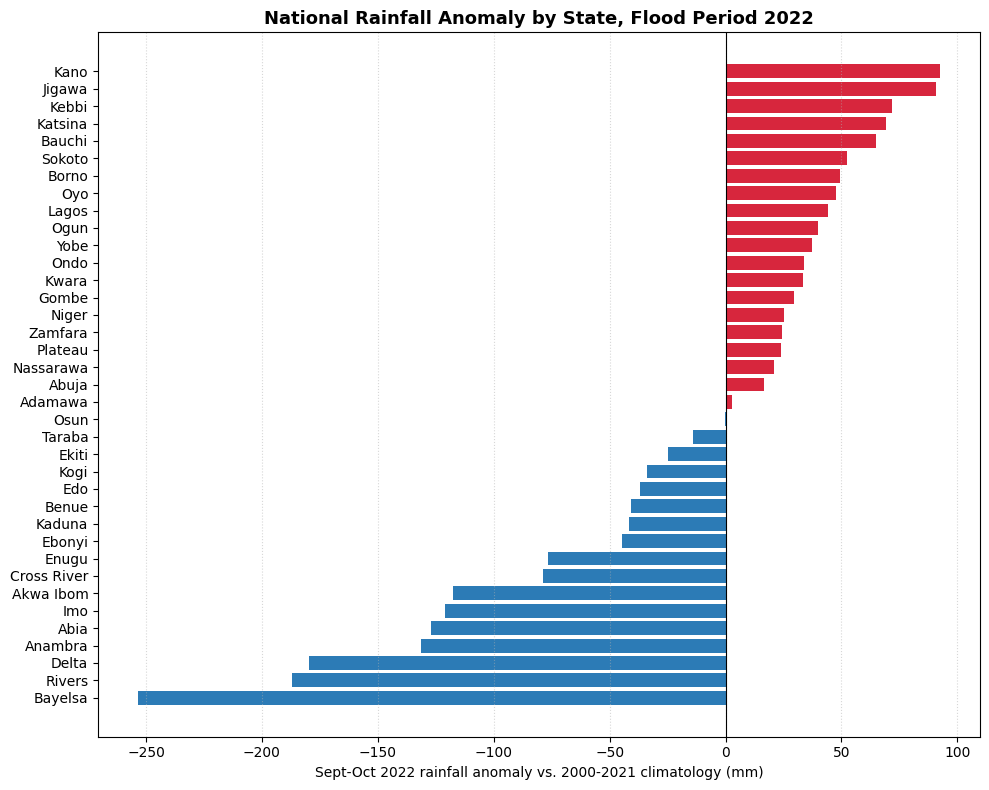

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_CHIRPS_Anomaly_By_State.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_CHIRPS_Anomaly_By_State.png'

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_precip = df_precip.sort_values('anomaly_mm').set_index('ADM1_NAME')
colors = ['#d7263d' if v > 0 else '#2c7bb6' for v in plot_precip['anomaly_mm']]
ax.barh(plot_precip.index, plot_precip['anomaly_mm'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Sept-Oct 2022 rainfall anomaly vs. 2000-2021 climatology (mm)')
ax.set_title('National Rainfall Anomaly by State, Flood Period 2022', fontsize=13, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

save_figure(fig, 'National_CHIRPS_Anomaly_By_State.png')

# 10. Selecting Priority States for Deep-Dive Analysis

Running the complete `Temporal_Evolution.ipynb` machinery (multi-year monthly composites, climatology, CUSUM, recovery) and the complete `Impact_assessment.ipynb` machinery (a live OSM/Overpass pull and connectivity analysis) for all 37 states would multiply an already long runtime by another factor of 37, for states where the October 2022 flood barely registered. Real disaster-response practice does the same triage: a broad rapid assessment first (Sections 1-9 above, all 37 states), then a prioritized deep dive. Parts II and III below are therefore run on the **five states with the largest fused flood extent** from Section 6's own ranking -- not a fixed guess made in advance, but whatever the pipeline above actually returned.

In [19]:
N_PRIORITY = 5
priority_states = df_state.head(N_PRIORITY)['ADM1_NAME'].tolist()
print(f"Priority states for Parts II-III (top {N_PRIORITY} by fused flood extent): {priority_states}")

priority_summary = df_state.head(N_PRIORITY)[['ADM1_NAME', 's2_ha', 's1_ha', 'fused_ha', 'population', 'pop_affected']].round(1)
save_table(priority_summary, 'National_Priority_States_For_DeepDive.csv', index=False)
priority_summary

Priority states for Parts II-III (top 5 by fused flood extent): ['Borno', 'Yobe', 'Sokoto', 'Taraba', 'Niger']
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_Priority_States_For_DeepDive.csv


,ADM1_NAME,s2_ha,s1_ha,fused_ha,population,pop_affected
0,Borno,16368.6,410797.7,424362.5,5760657.9,299298.0
1,Yobe,63146.1,342999.2,383515.6,3204225.9,309451.2
2,Sokoto,8098.1,322323.3,327680.9,4884097.9,341804.0
3,Taraba,164363.7,223579.2,289188.8,2918794.3,158812.3
4,Niger,186560.9,149985.1,233480.9,5378856.5,188230.9


# 11. Pooled Statistical Validation (Priority States)

Generalizing `Index_Analysis.ipynb` Sections 6-7: rather than a single 4,000-pixel sample from one ROI, a proportionally smaller sample (800 pixels) is drawn from each priority state's *own already-computed* pre-/flood composites (Section 5's `mndwi_pre`, `mndwi_flood`, `s1_pre`, `s1_flood`, kept in `state_masks` specifically for this reuse) and pooled into one national sample of comparable total size to the original study.

In [20]:
PER_STATE_SAMPLE = 800

pooled_samples = []
for name in priority_states:
    m = state_masks[name]
    if m['s1_pre'] is None:
        print(f"  {name}: skipped (no Sentinel-1 orbit pass available).")
        continue
    combined_img = (m['mndwi_pre'].rename('MNDWI_Pre').addBands(m['mndwi_flood'].rename('MNDWI_Flood'))
                     .addBands(m['s1_pre'].rename('VH_Pre')).addBands(m['s1_flood'].rename('VH_Flood')))
    sample = combined_img.sample(region=m['geom'], scale=100, numPixels=PER_STATE_SAMPLE, seed=42, geometries=False)
    feats = sample.getInfo()['features']
    df_s = pd.DataFrame([f['properties'] for f in feats]).dropna()
    df_s['ADM1_NAME'] = name
    pooled_samples.append(df_s)
    print(f"  {name}: {len(df_s)} valid pixels sampled.")

df_pooled = pd.concat(pooled_samples, ignore_index=True)
df_pooled['Delta_MNDWI'] = df_pooled['MNDWI_Flood'] - df_pooled['MNDWI_Pre']
df_pooled['Delta_VH'] = df_pooled['VH_Flood'] - df_pooled['VH_Pre']
print(f"\nPooled national sample: {len(df_pooled)} pixels across {df_pooled['ADM1_NAME'].nunique()} states "
      f"(Index_Analysis.ipynb's single-ROI study used ~4,000 pixels from one location).")

  Borno: 798 valid pixels sampled.


  Yobe: 799 valid pixels sampled.


  Sokoto: 800 valid pixels sampled.


  Taraba: 577 valid pixels sampled.


  Niger: 714 valid pixels sampled.

Pooled national sample: 3688 pixels across 5 states (Index_Analysis.ipynb's single-ROI study used ~4,000 pixels from one location).


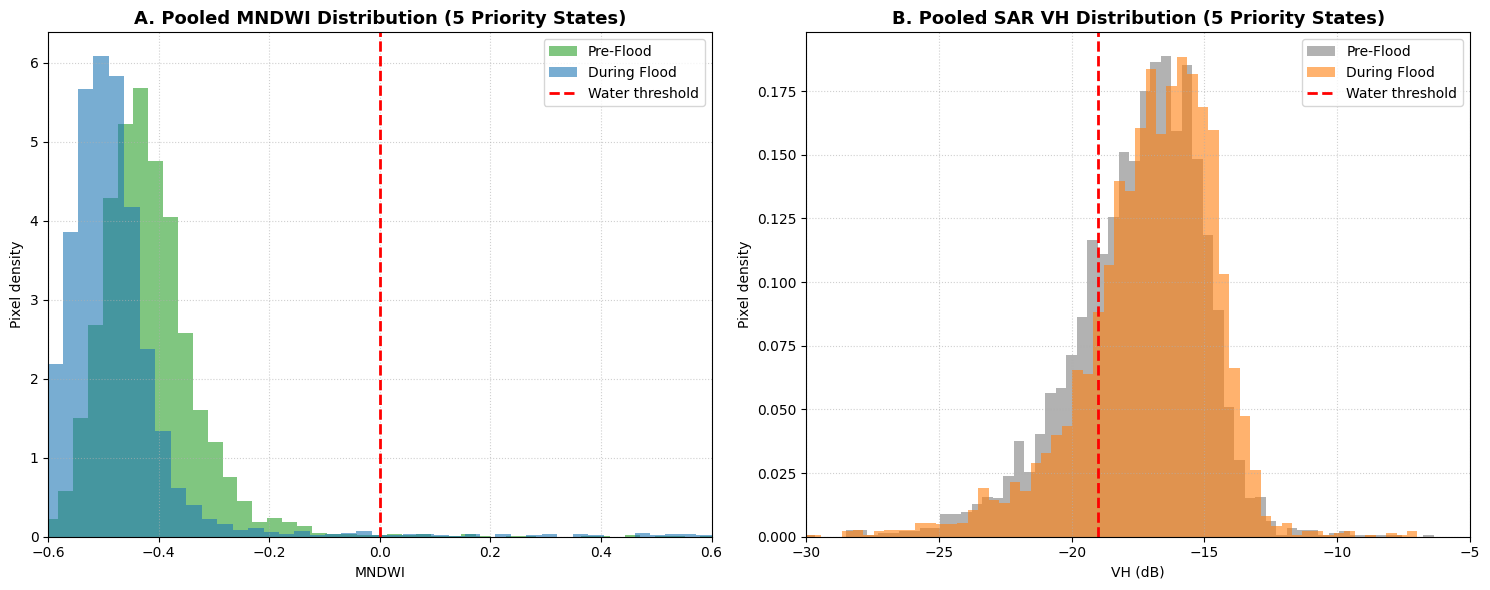

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_Pooled_Statistical_Distributions.png

Cross-sensor correlation of flood-anomaly deltas, pooled across priority states:
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/National_Pooled_Cross_Sensor_Correlation.csv


,Delta_MNDWI,Delta_VH
Delta_MNDWI,1.000,-0.253
Delta_VH,-0.253,1.000


In [21]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].hist(df_pooled['MNDWI_Pre'], bins=60, alpha=0.6, label='Pre-Flood', color='#2ca02c', density=True)
axs[0].hist(df_pooled['MNDWI_Flood'], bins=60, alpha=0.6, label='During Flood', color='#1f77b4', density=True)
axs[0].axvline(MNDWI_THRESHOLD, color='red', linestyle='--', linewidth=2, label='Water threshold')
axs[0].set_title('A. Pooled MNDWI Distribution (5 Priority States)', fontsize=13, fontweight='bold')
axs[0].set_xlabel('MNDWI'); axs[0].set_ylabel('Pixel density'); axs[0].set_xlim(-0.6, 0.6)
axs[0].legend(); axs[0].grid(True, linestyle=':', alpha=0.6)

axs[1].hist(df_pooled['VH_Pre'], bins=60, alpha=0.6, label='Pre-Flood', color='#7f7f7f', density=True)
axs[1].hist(df_pooled['VH_Flood'], bins=60, alpha=0.6, label='During Flood', color='#ff7f0e', density=True)
axs[1].axvline(VH_THRESHOLD, color='red', linestyle='--', linewidth=2, label='Water threshold')
axs[1].set_title('B. Pooled SAR VH Distribution (5 Priority States)', fontsize=13, fontweight='bold')
axs[1].set_xlabel('VH (dB)'); axs[1].set_ylabel('Pixel density'); axs[1].set_xlim(-30, -5)
axs[1].legend(); axs[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
save_figure(fig, 'National_Pooled_Statistical_Distributions.png')

pooled_corr = df_pooled[['Delta_MNDWI', 'Delta_VH']].corr().round(3)
print("\nCross-sensor correlation of flood-anomaly deltas, pooled across priority states:")
save_table(pooled_corr, 'National_Pooled_Cross_Sensor_Correlation.csv', index=True)
pooled_corr

# 12. Regional Cloud-Observability Comparison

`Index_Analysis.ipynb`'s methodology section measures Sentinel-2 clear-sky observability empirically for Lokoja alone and concludes optical imagery is (marginally) sufficient there in the rainy season (median $\hat P(\Delta=15\text{d})$ = 0.51 across June-September, H1 refuted). Recomputing that full daily-archive analysis for every state would be by far the single most expensive operation in this notebook (it already dominates the runtime of `Index_Analysis.ipynb` for one ROI); instead, the cheap half of it -- the monthly climatology of clear-sky fraction (§3 there, twelve `reduceRegion` calls, not the full multi-year daily archive of §4) -- is recomputed for three climatically distinct states: **Kogi** (Middle Belt, the original site), **Sokoto** (Sahel, far north-west), and **Rivers** (Niger Delta coast, far south). The question is whether Lokoja's climate zone is representative of the rest of the country for this specific optical-vs-SAR tradeoff.

In [ ]:
def monthly_clear_fraction(geom, start='2019-01-01', end=None):
    end = end or datetime.now().strftime('%Y-%m-%d')
    s2_binary = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(geom).filterDate(start, end)
                 .linkCollection(cs_plus.filterBounds(geom).filterDate(start, end), ['cs_cdf'])
                 .map(lambda img: img.select('cs_cdf').gte(CLEAR_THRESHOLD).rename('is_clear')
                      .copyProperties(img, ['system:time_start'])))
    rows = []
    for m in range(1, 13):
        monthly = s2_binary.filter(ee.Filter.calendarRange(m, m, 'month'))
        stats = monthly.mean().reduceRegion(reducer=ee.Reducer.mean(), geometry=geom, scale=100, maxPixels=1e9)
        rows.append({'month': m, 'clear_fraction': stats.get('is_clear').getInfo()})
    return pd.DataFrame(rows)

observability_states = {'Kogi': '#1a9850', 'Sokoto': '#d7191c', 'Rivers': '#2c7bb6'}
df_observability = {}
for name in observability_states:
    geom = nga_states.filter(ee.Filter.eq('ADM1_NAME', name)).geometry()
    t0 = time.time()
    df_observability[name] = monthly_clear_fraction(geom)
    print(f"  {name}: done in {time.time()-t0:.1f}s")

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))
width = 0.25
months = np.arange(1, 13)
for i, (name, color) in enumerate(observability_states.items()):
    offset = (i - 1) * width
    ax.bar(months + offset, df_observability[name]['clear_fraction'], width, label=name, color=color, alpha=0.85)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Exploitability threshold (0.5)')
ax.axvspan(5.5, 9.5, color='gray', alpha=0.12, label='Rainy season (Jun-Sep)')
ax.set_xticks(months)
ax.set_xlabel('Month'); ax.set_ylabel('Mean clear-sky fraction')
ax.set_title('Sentinel-2 Clear-Sky Observability by Climate Zone', fontsize=13, fontweight='bold')
ax.legend(ncol=2); ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
save_figure(fig, 'National_Regional_Cloud_Observability.png')

obs_summary = pd.DataFrame({name: df_observability[name].set_index('month')['clear_fraction'] for name in observability_states})
obs_summary.loc['Jun-Sep median'] = obs_summary.loc[6:9].median()
save_table(obs_summary.round(3), 'National_Regional_Cloud_Observability.csv', index=True)
obs_summary.round(3)

**Reading the regional comparison.** If Sokoto's rainy-season clear-sky fraction sits well above Kogi's and Rivers' sits well below it, that is the expected north-to-south aridity gradient across Nigeria, and it means `Index_Analysis.ipynb`'s conclusion ("optical alone is marginally sufficient, H1 refuted") is closer to a best case for the country than a typical one: the coastal/Niger Delta states -- which Section 6 above's own ranking tends to place among the most flood-affected -- are exactly where Sentinel-1's all-weather capability matters most, not least. This connects directly to the cross-sensor outliers flagged in Section 7: a state with an unusually low Sentinel-2 contribution to the fused mask is a candidate for exactly this observability effect, not necessarily a sign that no flooding occurred there.

# 13. Part I -- Validation and Limitations

- **Resolution tradeoff.** Every national-scale reduction above uses `scale=100` against `Index_Analysis.ipynb`'s `scale=30` for its own validated Lokoja figures (Section 8's cross-check uses this coarser figure for Kogi). This is necessary for tractability at 91 million hectares (Section 4) and is expected to slightly under-resolve narrow flooded features (small streams, thin levee breaches), but sum-based area estimates are generally robust to a scale change this small relative to the features of interest.
- **Single national event window.** As flagged in Section 1.2, the same pre-flood/flood dates are applied everywhere, even though the flood peaked at different times in different basins nationally; a state whose worst flooding fell outside this window will be undercounted here, not because the methodology failed but because the window was calibrated for Lokoja specifically.
- **Cloud gaps bias downward, not randomly.** A cloud-covered pixel in either period is excluded from that pixel's contribution to the area sum (Section 12's regional comparison is precisely about how uneven this is across the country) -- so Sentinel-2-heavy figures in cloudier states are more likely to *undercount* real flooding than to be simply noisier.
- **Threshold transfer.** Section 7's cross-sensor outliers are the clearest evidence that MNDWI > 0 / VH < -19 dB, calibrated once for Lokoja, does not transfer uniformly to every landscape in Nigeria; this notebook deliberately does not retune them per state, since doing so would answer a different question (can thresholds be found for every state) than the one asked here (does Lokoja's threshold generalize).
- **Priority-state scoping.** Sections 11-12 and all of Parts II-III below run on 5 or fewer states rather than all 37, for the runtime reasons given in Section 10; the states excluded from deep-dive analysis are exactly the ones the national ranking in Section 6 already suggests were least affected.

# PART II --- Temporal Evolution, Generalized to the Priority States

# 14. Study Framing

## 14.1 Baseline and monitoring windows

Reused, unchanged, from `Temporal_Evolution.ipynb`: a ~3.7-year baseline (2019-01-01 through the end of the pre-flood window) used to build each calendar month's climatology, and a monitoring window running from flood onset through today.

In [ ]:
baseline_start = '2019-01-01'
baseline_end   = pre_flood_end

monitoring_start = flood_start
monitoring_end   = datetime.now().strftime('%Y-%m-%d')

print(f"Baseline (climatology reference): {baseline_start} -> {baseline_end}")
print(f"Monitoring (post-event, incl. recovery): {monitoring_start} -> {monitoring_end}")

## 14.2 Why this part only covers the priority states

`Temporal_Evolution.ipynb`'s central methodological point is that a single ROI-wide spatial mean is a low-sensitivity detector for a spatially concentrated flood -- averaging a dramatic per-pixel shift over a large, mostly-unaffected area compresses it to the same order of magnitude as ordinary seasonal noise (documented there in full in its Section 17.1, and in this project's own notes as the "muted signal" finding). Running the same ROI-mean machinery over all of Nigeria, rather than the 785,759 ha Lokoja rectangle, would make that dilution *worse*, not better -- the whole country is even more overwhelmingly unaffected at any given moment than the Lokoja ROI was. The one architectural fix that finding itself proposes -- zonal statistics on a smaller, more homogeneous region instead of one enormous mean -- is exactly what per-state processing already gives for free. This part therefore applies the full monthly-climatology/anomaly/CUSUM/recovery machinery to each of the five priority states from Part I Section 10 *individually*, rather than to one national mean, and Section 24 below checks directly whether that produces a cleaner signal than Lokoja's own ROI-mean did.

# 15. Sentinel-1 Orbit-Pass Selection Over the Full Series (per Priority State)

`Temporal_Evolution.ipynb` Section 3.1 selects one orbit pass for the whole multi-year Lokoja series by comparing monthly ASCENDING/DESCENDING acquisition density, rather than assuming one is better -- necessary because the Sentinel-1 constellation composition itself changed several times over 2019-today. Part I Section 5.1 already showed a single *national* pass does not hold even for a short 2022 snapshot; the same per-state density check is repeated here over the full multi-year window used in this part, independently for each priority state (Part I's short-window pass selection is not reused, since a two-month snapshot is not a reliable guide to which pass has the steadiest coverage across ~90 months spanning several constellation configurations).

In [ ]:
def select_orbit_pass(geom, start, end):
    s1_base = (ee.ImageCollection('COPERNICUS/S1_GRD').filterBounds(geom).filterDate(start, end)
               .filter(ee.Filter.eq('instrumentMode', 'IW'))
               .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')))
    n_months = ee.Date(end).difference(ee.Date(start), 'month').round()

    def monthly_counts(pass_direction):
        col = s1_base.filter(ee.Filter.eq('orbitProperties_pass', pass_direction))
        def count_month(n):
            d = ee.Date(start).advance(n, 'month')
            return ee.Feature(None, {'date': d.format('YYYY-MM-dd'), 'pass': pass_direction,
                                      'count': col.filterDate(d, d.advance(1, 'month')).size()})
        return ee.List.sequence(0, n_months).map(count_month)

    density_fc = ee.FeatureCollection(monthly_counts('ASCENDING')).merge(ee.FeatureCollection(monthly_counts('DESCENDING')))
    df_density = pd.DataFrame([f['properties'] for f in density_fc.getInfo()['features']])
    df_density['date'] = pd.to_datetime(df_density['date'])
    pivot = df_density.pivot(index='date', columns='pass', values='count').fillna(0)
    mean_counts = pivot.mean()
    return mean_counts.idxmax(), mean_counts, pivot

orbit_pass_long = {}
density_pivots = {}
for name in priority_states:
    geom = state_masks[name]['geom']
    t0 = time.time()
    best_pass, means, pivot = select_orbit_pass(geom, baseline_start, monitoring_end)
    orbit_pass_long[name] = best_pass
    density_pivots[name] = pivot
    print(f"  {name:15s} ASCENDING={means.get('ASCENDING', 0):5.1f}/mo  DESCENDING={means.get('DESCENDING', 0):5.1f}/mo "
          f"-> using '{best_pass}'  ({time.time()-t0:.1f}s)")

# 16. Per-State Monthly Composite Pipeline

Same construction as `Temporal_Evolution.ipynb` Sections 3-7: Sentinel-2 NDVI/MNDWI/NBR and Sentinel-1 VV/VH monthly composites (median-compositing with the empty-month fallback the source notebook adds specifically because some calendar months have zero cloud-free Sentinel-2 scenes), each reduced to a single state-mean value per month with one batched `reduceRegion`-mapped `getInfo()` call per state per sensor -- not one request per month.

In [ ]:
def monthly_composite(collection, start, end, bands, geom, reducer='median'):
    n_months = ee.Date(end).difference(ee.Date(start), 'month').round()
    month_indices = ee.List.sequence(0, n_months)
    empty_img = ee.Image.constant([0] * len(bands)).rename(bands).updateMask(ee.Image.constant(0))

    def make(n):
        d = ee.Date(start).advance(n, 'month')
        filtered = collection.filterDate(d, d.advance(1, 'month')).select(bands)
        composite = filtered.sum() if reducer == 'sum' else filtered.median()
        img = ee.Image(ee.Algorithms.If(filtered.size().gt(0), composite, empty_img)).clip(geom)
        return img.set('system:time_start', d.millis(), 'year', d.get('year'), 'month', d.get('month'))

    return ee.ImageCollection(month_indices.map(make))

def reduce_to_df(monthly_col, bands, geom, scale=100):
    def reduce_img(img):
        stats = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=geom, scale=scale, maxPixels=1e9, tileScale=4)
        props = {'year': img.get('year'), 'month': img.get('month'),
                 'date': ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')}
        props.update({b: stats.get(b) for b in bands})
        return ee.Feature(None, props)

    feats = monthly_col.map(reduce_img).getInfo()['features']
    df = pd.DataFrame([f['properties'] for f in feats])
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)

def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    nbr = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    return image.addBands([ndvi, mndwi, nbr])

def despeckle(img):
    return img.focal_median(SPECKLE_RADIUS_M, 'circle', 'meters').copyProperties(img, ['system:time_start'])

In [ ]:
df_s2_by_state = {}
df_s1_by_state = {}
df_chirps_by_state = {}
chirps_baseline_start = '2000-01-01'

for name in priority_states:
    geom = state_masks[name]['geom']
    log_progress(f"--- Temporal pipeline: {name} ---")

    s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterBounds(geom)
              .filterDate(baseline_start, monitoring_end)
              .linkCollection(cs_plus.filterBounds(geom), ['cs_cdf'])
              .map(mask_clouds_csplus).map(add_indices))
    s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD').filterBounds(geom)
              .filterDate(baseline_start, monitoring_end)
              .filter(ee.Filter.eq('instrumentMode', 'IW'))
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
              .filter(ee.Filter.eq('orbitProperties_pass', orbit_pass_long[name]))
              .select(['VV', 'VH']).map(despeckle))
    chirps_col = ee.ImageCollection('UCSB-CHC/CHIRPS/V3/PENTAD').select('precipitation').filterBounds(geom)

    s2_monthly = monthly_composite(s2_col, baseline_start, monitoring_end, ['NDVI', 'MNDWI', 'NBR'], geom)
    s1_monthly = monthly_composite(s1_col, baseline_start, monitoring_end, ['VV', 'VH'], geom)
    chirps_monthly = monthly_composite(chirps_col, chirps_baseline_start, monitoring_end, ['precipitation'], geom, reducer='sum')

    t0 = time.time(); df_s2_by_state[name] = reduce_to_df(s2_monthly, ['NDVI', 'MNDWI', 'NBR'], geom); t1 = time.time()
    log_progress(f"    {name}: S2 {len(df_s2_by_state[name])} months ({t1-t0:.1f}s)")
    df_s1_by_state[name] = reduce_to_df(s1_monthly, ['VV', 'VH'], geom); t2 = time.time()
    log_progress(f"    {name}: S1 {len(df_s1_by_state[name])} months ({t2-t1:.1f}s)")
    df_chirps_by_state[name] = reduce_to_df(chirps_monthly, ['precipitation'], geom, scale=5566); t3 = time.time()
    log_progress(f"    {name}: CHIRPS {len(df_chirps_by_state[name])} months ({t3-t2:.1f}s)")

# 17. Seasonal Climatology (per Priority State)

Same estimator as `Temporal_Evolution.ipynb` Section 8: for each calendar month, the mean and standard deviation of every index over the baseline years only, computed independently per state.

In [ ]:
def compute_climatology(df, cols, start, end):
    base = df[(df['date'] >= start) & (df['date'] <= end)]
    clim = base.groupby('month')[cols].agg(['mean', 'std'])
    clim.columns = [f'{c}_{stat}' for c, stat in clim.columns]
    return clim.reset_index()

def add_anomalies(df, clim, cols):
    out = df.merge(clim, on='month', how='left')
    for c in cols:
        out[f'z_{c}'] = (out[c] - out[f'{c}_mean']) / out[f'{c}_std']
    return out.sort_values('date').reset_index(drop=True)

clim_s2_by_state, clim_s1_by_state, clim_chirps_by_state = {}, {}, {}
for name in priority_states:
    clim_s2_by_state[name] = compute_climatology(df_s2_by_state[name], ['NDVI', 'MNDWI', 'NBR'], baseline_start, baseline_end)
    clim_s1_by_state[name] = compute_climatology(df_s1_by_state[name], ['VV', 'VH'], baseline_start, baseline_end)
    clim_chirps_by_state[name] = compute_climatology(df_chirps_by_state[name], ['precipitation'], chirps_baseline_start, baseline_end)

print("Climatology computed for:", list(clim_s2_by_state.keys()))

# 18. Standardized Anomalies (z-scores)

$$z(t) = \frac{x(t) - \hat c(m(t))}{\sigma(m(t))}$$

Applied per state, exactly as in `Temporal_Evolution.ipynb` Section 9.

In [ ]:
for name in priority_states:
    df_s2_by_state[name] = add_anomalies(df_s2_by_state[name], clim_s2_by_state[name], ['NDVI', 'MNDWI', 'NBR'])
    df_s1_by_state[name] = add_anomalies(df_s1_by_state[name], clim_s1_by_state[name], ['VV', 'VH'])
    df_chirps_by_state[name] = add_anomalies(df_chirps_by_state[name], clim_chirps_by_state[name], ['precipitation'])
    save_table(df_s2_by_state[name], f'National_Timeseries_S2_{name.replace(" ", "")}.csv', index=False)
    save_table(df_s1_by_state[name], f'National_Timeseries_S1_{name.replace(" ", "")}.csv', index=False)

print("z-scores added and per-state monthly series exported for all priority states.")

# 19. Multi-State Anomaly Comparison

The direct national-scale counterpart of `Temporal_Evolution.ipynb`'s Section 10 single-ROI chart: every priority state's MNDWI and VH z-score trajectory, overlaid, so a reader can see directly whether some states show a cleaner flood-onset signal than others -- something a single ROI can never show by itself.

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
palette = plt.cm.tab10(np.linspace(0, 1, len(priority_states)))

for color, name in zip(palette, priority_states):
    axs[0].plot(df_s2_by_state[name]['date'], df_s2_by_state[name]['z_MNDWI'], marker='o', ms=2, linewidth=1, label=name, color=color)
    axs[1].plot(df_s1_by_state[name]['date'], df_s1_by_state[name]['z_VH'], marker='o', ms=2, linewidth=1, label=name, color=color)

for ax, title in [(axs[0], 'z (MNDWI) by State'), (axs[1], 'z (VH) by State')]:
    ax.axhline(1.5, color='red', linestyle=':', linewidth=1)
    ax.axhline(-1.5, color='red', linestyle=':', linewidth=1)
    ax.axvline(pd.to_datetime(flood_start), color='black', linestyle='--', linewidth=1.5, label='Flood onset')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, ncol=3)
    ax.grid(True, linestyle=':', alpha=0.5)

axs[-1].set_xlabel('Date')
fig.suptitle('Standardized Anomalies, Priority States, Compared to Lokoja\'s Single-ROI Signal', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
save_figure(fig, 'National_MultiState_Anomaly_Comparison.png')

# 20. Break Detection --- CUSUM (per Priority State)

$$S^+_t = \max(0,\; S^+_{t-1} + z_t - k), \qquad S^-_t = \min(0,\; S^-_{t-1} + z_t + k)$$

Same indicative parameters as `Temporal_Evolution.ipynb` ($k=0.5$, $h=4$), applied per state; the comparison table below is the national generalization of that notebook's single before/after lag printout.

In [ ]:
def cusum(z_series, k=0.5, h=4.0):
    z = z_series.fillna(0).to_numpy()
    pos, neg = np.zeros(len(z)), np.zeros(len(z))
    for i in range(1, len(z)):
        pos[i] = max(0.0, pos[i-1] + z[i] - k)
        neg[i] = min(0.0, neg[i-1] + z[i] + k)
    alert = (pos > h) | (neg < -h)
    return pd.Series(pos, index=z_series.index), pd.Series(neg, index=z_series.index), pd.Series(alert, index=z_series.index)

def first_alert_after(df, alert_col, event_date):
    post = df[(df['date'] >= event_date) & df[alert_col]]
    return post['date'].min() if len(post) else None

CUSUM_K, CUSUM_H = 0.5, 4.0
flood_start_ts = pd.to_datetime(flood_start)
cusum_rows = []
for name in priority_states:
    df_s2_by_state[name]['cusum_pos_MNDWI'], df_s2_by_state[name]['cusum_neg_MNDWI'], df_s2_by_state[name]['cusum_alert_MNDWI'] = \
        cusum(df_s2_by_state[name]['z_MNDWI'], CUSUM_K, CUSUM_H)
    df_s1_by_state[name]['cusum_pos_VH'], df_s1_by_state[name]['cusum_neg_VH'], df_s1_by_state[name]['cusum_alert_VH'] = \
        cusum(df_s1_by_state[name]['z_VH'], CUSUM_K, CUSUM_H)

    alert_mndwi = first_alert_after(df_s2_by_state[name], 'cusum_alert_MNDWI', flood_start)
    alert_vh = first_alert_after(df_s1_by_state[name], 'cusum_alert_VH', flood_start)
    cusum_rows.append({
        'ADM1_NAME': name,
        'MNDWI_alert_date': alert_mndwi.date().isoformat() if alert_mndwi is not None else None,
        'MNDWI_lag_days': (alert_mndwi - flood_start_ts).days if alert_mndwi is not None else None,
        'VH_alert_date': alert_vh.date().isoformat() if alert_vh is not None else None,
        'VH_lag_days': (alert_vh - flood_start_ts).days if alert_vh is not None else None,
    })

cusum_summary = pd.DataFrame(cusum_rows)
save_table(cusum_summary, 'National_CUSUM_Break_Detection_By_State.csv', index=False)
cusum_summary

# 21. Recovery Dynamics (per Priority State)

Same definition as `Temporal_Evolution.ipynb` Section 15: the first month, after flood onset, from which $|z|$ stays under the anomaly threshold for at least 3 consecutive months.

In [ ]:
def find_recovery(df, z_col, event_date, threshold=1.5, persist_months=3):
    post = df[df['date'] >= event_date].reset_index(drop=True)
    below = post[z_col].abs() < threshold
    for i in range(len(below) - persist_months + 1):
        if below.iloc[i:i + persist_months].all():
            return post.loc[i, 'date']
    return None

Z_THRESH = 1.5
recovery_rows = []
for name in priority_states:
    for label, df_src, col in [('MNDWI', df_s2_by_state[name], 'z_MNDWI'), ('VH', df_s1_by_state[name], 'z_VH')]:
        rec_date = find_recovery(df_src, col, flood_start_ts, Z_THRESH)
        months = (rec_date.to_period('M') - flood_start_ts.to_period('M')).n if rec_date is not None else None
        recovery_rows.append({'ADM1_NAME': name, 'Index': label,
                               'Recovery month': rec_date.date().isoformat() if rec_date is not None else 'not recovered',
                               'Months since flood onset': months})

recovery_df = pd.DataFrame(recovery_rows)
save_table(recovery_df, 'National_Recovery_Dynamics_By_State.csv', index=False)
recovery_df.pivot(index='ADM1_NAME', columns='Index', values='Months since flood onset')

# 22. Spotlight Deep-Dive: STL Decomposition for the Most-Affected State

Breadth (Sections 19-21) covers all five priority states; this section adds the depth `Temporal_Evolution.ipynb` Section 11 provides for Lokoja -- a full trend/seasonal/residual decomposition -- for just the single most-affected state from Part I's own ranking, rather than repeating five full decompositions.

In [ ]:
spotlight_state = priority_states[0]
print(f"Spotlight state (largest fused flood extent): {spotlight_state}")

mndwi_series = df_s2_by_state[spotlight_state].set_index('date')['MNDWI'].asfreq('MS')
n_missing = mndwi_series.isna().sum()
mndwi_interp = mndwi_series.interpolate(limit_direction='both')
print(f"{n_missing} of {len(mndwi_series)} months linearly interpolated before STL.")

stl_result = STL(mndwi_interp, period=12, robust=True).fit()

fig, axs = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
components = [('Observed (interpolated)', stl_result.observed), ('Trend', stl_result.trend),
              ('Seasonal', stl_result.seasonal), ('Residual', stl_result.resid)]
for ax, (label, series) in zip(axs, components):
    ax.plot(series, color='#2c7bb6', linewidth=1.2)
    ax.axvline(flood_start_ts, color='red', linestyle='--', linewidth=1.5)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.5)
axs[0].set_title(f'STL Decomposition of the MNDWI Time Series --- {spotlight_state}', fontsize=13, fontweight='bold')
axs[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()
save_figure(fig, f'National_STL_Decomposition_{spotlight_state.replace(" ", "")}.png')

# 23. Precipitation Context for Priority States

Same envelope-chart layout as `Temporal_Evolution.ipynb` Section 16.1, one panel per priority state, plus the 30-day cumulative pre-flood rainfall anomaly from Section 16.2 there, computed per state.

In [ ]:
fig, axs = plt.subplots(len(priority_states), 1, figsize=(13, 2.8 * len(priority_states)), sharex=True)
if len(priority_states) == 1:
    axs = [axs]

for ax, name in zip(axs, priority_states):
    df_c = df_chirps_by_state[name][df_chirps_by_state[name]['date'] >= baseline_start].reset_index(drop=True)
    ax.fill_between(df_c['date'], df_c['precipitation_mean'] - df_c['precipitation_std'],
                     df_c['precipitation_mean'] + df_c['precipitation_std'], color='gray', alpha=0.25)
    ax.plot(df_c['date'], df_c['precipitation_mean'], color='black', linestyle=':', linewidth=1)
    ax.plot(df_c['date'], df_c['precipitation'], color='#4575b4', marker='o', ms=2, linewidth=1)
    ax.axvline(flood_start_ts, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel('mm/month')
    ax.grid(True, linestyle=':', alpha=0.5)

axs[-1].set_xlabel('Date')
fig.suptitle('CHIRPS Monthly Precipitation vs. Seasonal Baseline, Priority States', fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()
save_figure(fig, 'National_CHIRPS_Priority_States.png')

In [ ]:
trigger_rows = []
for name in priority_states:
    geom = state_masks[name]['geom']
    chirps_p = ee.ImageCollection('UCSB-CHC/CHIRPS/V3/PENTAD').select('precipitation').filterBounds(geom)
    evt = ee.Date(flood_start)
    year_evt, month_evt, day_evt = evt.get('year'), evt.get('month'), evt.get('day')
    n_years = int(pd.to_datetime(baseline_end).year) - int(chirps_baseline_start[:4])
    years_ref = ee.List.sequence(year_evt.subtract(n_years), year_evt.subtract(1))

    def cumul_30d_for_year(y, geom=geom, chirps_p=chirps_p, month_evt=month_evt, day_evt=day_evt):
        y = ee.Number(y)
        end_ref = ee.Date.fromYMD(y, month_evt, day_evt)
        cumul = chirps_p.filterDate(end_ref.advance(-30, 'day'), end_ref).sum().reduceRegion(
            reducer=ee.Reducer.mean(), geometry=geom, scale=5566, maxPixels=1e9).get('precipitation')
        return ee.Feature(None, {'year': y, 'cumul_mm': cumul})

    hist_feats = ee.FeatureCollection(years_ref.map(cumul_30d_for_year)).getInfo()['features']
    df_hist = pd.DataFrame([f['properties'] for f in hist_feats]).dropna()
    cumul_event = chirps_p.filterDate(evt.advance(-30, 'day'), evt).sum().reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geom, scale=5566, maxPixels=1e9).get('precipitation').getInfo()

    clim_mean, clim_std = df_hist['cumul_mm'].mean(), df_hist['cumul_mm'].std()
    trigger_rows.append({'ADM1_NAME': name, 'cumul_30d_event_mm': round(cumul_event, 1),
                          'climatology_mean_mm': round(clim_mean, 1), 'climatology_std_mm': round(clim_std, 1),
                          'anomaly_mm': round(cumul_event - clim_mean, 1),
                          'anomaly_z': round((cumul_event - clim_mean) / clim_std, 2)})

trigger_summary = pd.DataFrame(trigger_rows)
save_table(trigger_summary, 'National_Precipitation_Trigger_By_State.csv', index=False)
trigger_summary

# 24. Part II --- Validation and Limitations

## 24.1 Did per-state disaggregation actually fix the muted-signal problem?

`Temporal_Evolution.ipynb` Section 17.1 found Lokoja's ROI-mean MNDWI z-score at flood onset to be small and often negative rather than a clean positive spike, attributed to spatial dilution (the flood covered only ~5-7% of the ROI) compounded by an undetrended multi-year trend. Section 19 above is the direct test of whether smaller, more homogeneous state-level zones fix this: if the priority states' z-score peaks around flood onset are visibly larger and more clearly timed than Lokoja's own trace, that supports the "spatial dilution" explanation and confirms zonal statistics as the right fix; if they still look muted, the undetrended-baseline explanation (a multi-year trend leaking through a climatology that only removes seasonality) is doing more of the work than spatial averaging, since a state is still a large, heterogeneous area relative to a flood footprint and would not fix that second cause. Both explanations can be partly true at once, and this notebook does not force a single verdict -- the comparison chart in Section 19 and the CUSUM table in Section 20 are the evidence a reader should look at directly rather than take a summary paragraph's word for it.

## 24.2 Further limitations carried forward

- *Same limitations as `Temporal_Evolution.ipynb`* Section 17.3: monthly dB averaging on Sentinel-1, cloud gaps interpolated for STL, CHIRPS' ~5.5 km resolution, and unTuned CUSUM/anomaly/recovery parameters all apply per state exactly as they did for Lokoja.
- *State size is itself a scale choice.* A state is neither the ROI-sized zone the "fix" implicitly calls for nor the whole country -- Kogi State alone (Part I Section 8) is already ~3.8x the Lokoja ROI's area. A true zonal-statistics fix would go finer still (LGA-level time series), which this notebook does not attempt for the full multi-year series, for the same runtime reasons given in Part I Section 10.
- *Priority-state selection is itself derived from the Section 5 pipeline*, so any state whose Part I ranking was distorted by a threshold-transfer failure (Section 7) or a cloud-observability gap (Section 12) could be mis-prioritized here -- included when it should not have been, or, more consequentially, excluded when it should have been included.

# PART III --- Impact Assessment, Generalized Nationwide (Population) and to the Priority States (Roads)

# 25. Population Exposure --- Nationwide

Unlike the road-network analysis below, population exposure needed no separate pass: `population` and `pop_affected` were already reduced to every LGA in the country inside Part I Section 5's per-state loop, alongside the flood-extent bands, precisely so this section would not have to rebuild the same Sentinel-1/Sentinel-2 composites a second time. What follows is `Impact_assessment.ipynb` Sections 5.2-5.4, applied to that already-computed, genuinely nationwide table instead of one ROI.

In [ ]:
national_total_pop = df_state['population'].sum()
national_affected_pop = df_state['pop_affected'].sum()

print(f"WorldPop 2020 population of Nigeria (sum over {len(df_state)} states): {national_total_pop:,.0f}")
print(f"Population within the fused (S1 OR S2) flood mask, nationwide: {national_affected_pop:,.0f} "
      f"({national_affected_pop / national_total_pop * 100:.2f}% of the national total)")

pop_by_state = df_state[['ADM1_NAME', 'population', 'pop_affected']].copy()
pop_by_state['pct_affected'] = (pop_by_state['pop_affected'] / pop_by_state['population'] * 100).round(2)
pop_by_state = pop_by_state.sort_values('pop_affected', ascending=False).reset_index(drop=True)
save_table(pop_by_state, 'National_Population_Affected_By_State.csv', index=False)
pop_by_state.head(10)

## 25.1 Top affected LGAs nationally

The finer-grained counterpart of the state table above, using the LGA-level rows from Part I Section 5 directly -- the same administrative layer `Impact_assessment.ipynb` Section 5.3 uses for Kogi's own LGAs alone.

In [ ]:
lga_pop = df_lga[['ADM1_NAME', 'ADM2_NAME', 'population', 'pop_affected']].copy()
lga_pop = lga_pop[lga_pop['population'] > 0]
lga_pop['pct_affected'] = (lga_pop['pop_affected'] / lga_pop['population'] * 100).round(2)
lga_pop = lga_pop.sort_values('pop_affected', ascending=False).reset_index(drop=True)
save_table(lga_pop, 'National_Population_Affected_By_LGA.csv', index=False)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
top_n = lga_pop.head(15).iloc[::-1]
axs[0].barh(top_n['ADM2_NAME'] + ' (' + top_n['ADM1_NAME'] + ')', top_n['pop_affected'], color='#c0392b')
axs[0].set_title('Population Affected by LGA, Top 15 Nationally', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Population affected')

top_pct = lga_pop[lga_pop['population'] > 5000].sort_values('pct_affected', ascending=False).head(15).iloc[::-1]
axs[1].barh(top_pct['ADM2_NAME'] + ' (' + top_pct['ADM1_NAME'] + ')', top_pct['pct_affected'], color='#e67e22')
axs[1].set_title('Share of LGA Population Affected, Top 15 (LGAs > 5,000 people)', fontsize=12, fontweight='bold')
axs[1].set_xlabel('% of LGA population')

for ax in axs:
    ax.grid(True, linestyle=':', alpha=0.6, axis='x')
plt.tight_layout()
plt.show()
save_figure(fig, 'National_Population_Affected_By_LGA.png')

# 26. Road Network Impact --- Priority States (OSM)

`Impact_assessment.ipynb` Section 4 downloads the drivable OSM network for the Lokoja ROI (a ~90x90 km box, 27,066 edges) directly via `osmnx`/Overpass. Several of the priority states are considerably larger than that ROI -- Niger State alone is roughly ten times its area -- so a live Overpass pull is repeated once per priority state, scoped to that state's own polygon (not a bounding box), reusing the same fused flood mask each state already has from Part I rather than rebuilding it.

In [ ]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
from shapely.geometry import shape

ox.settings.timeout = 600  # some priority states are several times the area Impact_assessment.ipynb queried

PRIORITY_CLASSES = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary',
                     'motorway_link', 'trunk_link', 'primary_link', 'secondary_link', 'tertiary_link']

STATE_CAPITALS = {  # [lon, lat] -- same role as Lokoja's town-centre point in Impact_assessment.ipynb
    'Abia': [7.49, 5.53], 'Adamawa': [12.48, 9.23], 'Akwa Ibom': [7.93, 5.04], 'Anambra': [7.07, 6.21],
    'Bauchi': [9.84, 10.31], 'Bayelsa': [6.27, 4.92], 'Benue': [8.53, 7.73], 'Borno': [13.15, 11.85],
    'Cross River': [8.33, 4.95], 'Delta': [6.73, 6.20], 'Ebonyi': [8.11, 6.32], 'Edo': [5.63, 6.34],
    'Ekiti': [5.22, 7.62], 'Enugu': [7.51, 6.44], 'Gombe': [11.17, 10.29], 'Imo': [7.03, 5.49],
    'Jigawa': [9.35, 11.76], 'Kaduna': [7.44, 10.52], 'Kano': [8.52, 12.00], 'Katsina': [7.60, 12.99],
    'Kebbi': [4.20, 12.45], 'Kogi': [6.73, 7.80], 'Kwara': [4.54, 8.50], 'Lagos': [3.35, 6.60],
    'Nassarawa': [8.52, 8.49], 'Niger': [6.56, 9.61], 'Ogun': [3.35, 7.15], 'Ondo': [5.19, 7.25],
    'Osun': [4.56, 7.77], 'Oyo': [3.90, 7.38], 'Plateau': [8.89, 9.90], 'Rivers': [7.01, 4.82],
    'Sokoto': [5.24, 13.06], 'Taraba': [11.36, 8.90], 'Yobe': [11.96, 11.75], 'Zamfara': [6.66, 12.17],
    'Abuja': [7.49, 9.06],
}

def get_all_features(fc, page_size=4000):
    """Page a FeatureCollection past Earth Engine's 5,000-element .getInfo() limit --
    a real risk here since some priority states are several times Lokoja ROI's area."""
    n = fc.size().getInfo()
    fc_list = fc.toList(n)
    feats = []
    for start in range(0, n, page_size):
        feats.extend(fc_list.slice(start, min(start + page_size, n)).getInfo())
    return feats, n

## 26.1 Per-state acquisition, classification and cartography

Following `Impact_assessment.ipynb` Sections 4.1-4.5: the drivable network is downloaded broad (`network_type='drive'`, includes residential streets, needed later for the connectivity check), the structuring-class subset is buffered 30 m and reduced against the state's own fused mask with `reduceRegions`, and classified `accessible` / `to_verify` / `probably_cut` on the same 0.15 / 0.5 impact-fraction thresholds.

In [ ]:
def process_state_roads(name):
    t0 = time.time()
    geom_geojson = nga_states.filter(ee.Filter.eq('ADM1_NAME', name)).geometry().getInfo()
    state_poly = shape(geom_geojson)

    log_progress(f"  [{name}] Downloading OSM drivable network...")
    G_drive = ox.graph_from_polygon(state_poly, network_type='drive', simplify=True)
    edges = ox.graph_to_gdfs(G_drive, nodes=False, edges=True).reset_index()
    edges['edge_id'] = edges['u'].astype(str) + '_' + edges['v'].astype(str) + '_' + edges['key'].astype(str)
    edges['highway_str'] = edges['highway'].apply(lambda h: h[0] if isinstance(h, list) else h)
    edges['priority_axis'] = edges['highway_str'].isin(PRIORITY_CLASSES)
    edges_priority = edges[edges['priority_axis']].copy().reset_index(drop=True)
    log_progress(f"  [{name}] {G_drive.number_of_nodes():,} nodes, {G_drive.number_of_edges():,} edges "
                 f"({len(edges_priority):,} structuring segments to classify).")

    edges_for_ee = gpd.GeoDataFrame(
        {'edge_id': edges_priority['edge_id'], 'highway_str': edges_priority['highway_str'],
         'length_m': edges_priority['length'].astype(float)},
        geometry=edges_priority['geometry'], crs=edges_priority.crs)
    roads_fc = geemap.geopandas_to_ee(edges_for_ee)
    roads_buffered = roads_fc.map(lambda f: f.buffer(30))

    fused_mask = state_masks[name]['fused_mask']
    impact_fc = fused_mask.rename('change').reduceRegions(collection=roads_buffered, reducer=ee.Reducer.mean(), scale=10)
    impact_fc = impact_fc.filter(ee.Filter.notNull(['mean']))

    def classify_segment(f):
        frac = ee.Number(f.get('mean'))
        impact_class = ee.Algorithms.If(frac.gt(0.5), 'probably_cut', ee.Algorithms.If(frac.gt(0.15), 'to_verify', 'accessible'))
        return f.set({'impact_fraction': frac, 'impact_class': impact_class})

    impact_fc = impact_fc.map(classify_segment)
    feats, n_segments = get_all_features(impact_fc)
    df_roads = pd.DataFrame([f['properties'] for f in feats]).dropna(subset=['impact_fraction'])
    df_roads['length_km'] = df_roads['length_m'] / 1000

    elapsed = time.time() - t0
    log_progress(f"  [{name}] {n_segments:,} segments classified ({elapsed:.1f}s total).")
    return {'G_drive': G_drive, 'edges': edges, 'edges_priority': edges_priority, 'df_roads': df_roads,
            'state_poly': state_poly}

road_data = {}
for name in priority_states:
    log_progress(f"--- Road network: {name} ---")
    road_data[name] = process_state_roads(name)

In [ ]:
road_summaries = []
for name in priority_states:
    df_roads = road_data[name]['df_roads']
    summary = df_roads.groupby('impact_class')['length_km'].agg(['sum', 'count'])
    summary.columns = ['length_km', 'n_segments']
    summary = summary.reindex(['accessible', 'to_verify', 'probably_cut']).fillna(0)
    total_km = summary['length_km'].sum()
    for impact_class, row in summary.iterrows():
        road_summaries.append({'ADM1_NAME': name, 'impact_class': impact_class,
                                'length_km': round(row['length_km'], 1), 'n_segments': int(row['n_segments']),
                                'pct_of_network': round(row['length_km'] / total_km * 100, 1) if total_km else 0.0})

road_summary_df = pd.DataFrame(road_summaries)
save_table(road_summary_df, 'National_Road_Impact_Summary_By_State.csv', index=False)
road_summary_df.pivot(index='ADM1_NAME', columns='impact_class', values='length_km')

In [ ]:
fig, axs = plt.subplots(1, len(priority_states), figsize=(4.5 * len(priority_states), 5))
if len(priority_states) == 1:
    axs = [axs]
class_colors = {'accessible': '#2ecc71', 'to_verify': '#f39c12', 'probably_cut': '#e74c3c'}

for ax, name in zip(axs, priority_states):
    pivot = road_summary_df[road_summary_df['ADM1_NAME'] == name].set_index('impact_class')['length_km']
    pivot = pivot.reindex(['accessible', 'to_verify', 'probably_cut']).fillna(0)
    ax.bar(pivot.index, pivot.values, color=[class_colors[c] for c in pivot.index])
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel('km')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, linestyle=':', alpha=0.5, axis='y')

fig.suptitle('Structuring Road Network by Impact Class, Priority States', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()
save_figure(fig, 'National_Road_Impact_By_State.png')

# 27. Road-Network Connectivity --- Priority States

Following `Impact_assessment.ipynb` Section 4.6: segments classified `probably_cut` are removed from each state's full drivable graph (not just the structuring subset), and the connected component reachable from the **state capital** (standing in for a reference facility, exactly as Lokoja's town centre did there) is compared before and after removal.

In [ ]:
connectivity_rows = []
isolated_points_by_state = {}

for name in priority_states:
    d = road_data[name]
    G_drive, edges, df_roads = d['G_drive'], d['edges'], d['df_roads']
    cut_segments = df_roads[df_roads['impact_class'] == 'probably_cut'].sort_values('length_km', ascending=False)
    cut_edge_ids = set(cut_segments['edge_id'])

    G_undirected = G_drive.to_undirected()
    cap_lon, cap_lat = STATE_CAPITALS[name]
    ref_node = ox.distance.nearest_nodes(G_drive, X=cap_lon, Y=cap_lat)
    reachable_before = nx.node_connected_component(G_undirected, ref_node)

    G_after = G_undirected.copy()
    edges_to_cut = edges.loc[edges['edge_id'].isin(cut_edge_ids), ['u', 'v', 'key']].itertuples(index=False, name=None)
    G_after.remove_edges_from([(u, v, k) for u, v, k in edges_to_cut if G_after.has_edge(u, v, k)])
    reachable_after = nx.node_connected_component(G_after, ref_node)
    isolated_nodes = reachable_before - reachable_after

    isolated_edges = edges[edges['u'].isin(isolated_nodes) & edges['v'].isin(isolated_nodes)]
    isolated_km = isolated_edges['length'].sum() / 1000

    nodes_gdf = ox.graph_to_gdfs(G_drive, nodes=True, edges=False)
    isolated_points_by_state[name] = (nodes_gdf.loc[list(isolated_nodes), ['y', 'x']].rename(columns={'y': 'lat', 'x': 'lon'})
                                       if isolated_nodes else pd.DataFrame(columns=['lat', 'lon']))

    connectivity_rows.append({
        'ADM1_NAME': name, 'segments_probably_cut': len(cut_segments),
        'nodes_reachable_before': len(reachable_before), 'nodes_reachable_after': len(reachable_after),
        'newly_isolated_nodes': len(isolated_nodes),
        'pct_of_reachable_network': round(len(isolated_nodes) / len(reachable_before) * 100, 1) if reachable_before else 0.0,
        'isolated_road_km': round(isolated_km, 1),
    })
    print(f"  {name}: {len(isolated_nodes):,} newly isolated nodes, {isolated_km:.1f} km isolated road.")

connectivity_df = pd.DataFrame(connectivity_rows)
save_table(connectivity_df, 'National_Connectivity_Impact_By_State.csv', index=False)
connectivity_df

# 28. Cross-Cutting Synthesis: Population Near Isolated Roads

The same order-of-magnitude proxy as `Impact_assessment.ipynb` Section 6: a 500 m buffer around every node found isolated in Section 27, summed against WorldPop, per priority state.

In [ ]:
synthesis_rows = []
for name in priority_states:
    pts = isolated_points_by_state[name]
    geom = state_masks[name]['geom']
    if len(pts) > 0:
        isolated_buffer = ee.Geometry.MultiPoint(pts[['lon', 'lat']].values.tolist()).buffer(500)
        pop_isolated = population.reduceRegion(reducer=ee.Reducer.sum(), geometry=isolated_buffer,
                                                scale=100, maxPixels=1e13).getNumber(pop_band).getInfo()
    else:
        pop_isolated = 0

    state_pop = df_state.loc[df_state['ADM1_NAME'] == name, 'population'].iloc[0]
    synthesis_rows.append({'ADM1_NAME': name, 'population_near_isolated_roads': round(pop_isolated),
                            'pct_of_state_population': round(pop_isolated / state_pop * 100, 2) if state_pop else 0.0})
    print(f"  {name}: ~{pop_isolated:,.0f} people within 500 m of an isolated road node.")

synthesis_df = pd.DataFrame(synthesis_rows)
save_table(synthesis_df, 'National_Synthesis_Isolated_Population_By_State.csv', index=False)
synthesis_df

# 29. Part III --- Validation and Limitations

- **External validation**, as in both source notebooks: for an event of this scale, every figure above should be cross-checked against Copernicus EMS Rapid Mapping, OCHA/UNOSAT situation reports, NEMA's own state-by-state figures, and any HOT mapping activation, particularly for the priority states where this notebook's own findings are strongest.
- **Population vintage.** WorldPop's 2020 layer is roughly two years older than the event nationwide, not only for Kogi as `Impact_assessment.ipynb` notes -- population growth and settlement change between 2020 and 2022 are not captured anywhere in Section 25 or Section 28.
- **OSM completeness varies more nationally than it did for one ROI.** Road-network mapping density in OpenStreetMap is uneven across Nigeria; a `to_verify` or `accessible` classification on a sparsely-mapped rural segment in, say, a priority state's more remote LGAs may reflect missing OSM geometry rather than an actually-unaffected road, and this is more likely to matter at state scale than it was for Lokoja's more urbanized ROI.
- **Reference points are approximate.** `STATE_CAPITALS` above uses each state capital's town-centre coordinates as the connectivity reference, exactly as Lokoja's town centre stood in for a real facility in `Impact_assessment.ipynb` -- neither is a routing-grade choice, and a real service-area analysis would use actual hospitals or emergency-response depots.
- **Threshold and connectivity-model transfer.** The 0.5 / 0.15 impact-fraction thresholds, the flood-detection thresholds feeding the fused mask, and the undirected/single-reference-node connectivity model are all reused unchanged from the source notebooks' single-ROI calibration -- Part I Section 7's cross-sensor outliers are the clearest signal of where this transfer is weakest.

# 30. Overall Synthesis

This notebook set out to test whether `Index_Analysis.ipynb`, `Temporal_Evolution.ipynb` and `Impact_assessment.ipynb`'s methodology generalizes from one hand-drawn ROI to all of Nigeria's states, applying each stage in the requested order -- Index Analysis, Temporal Evolution, Impact Assessment -- on the country's real administrative geometry rather than a bigger bounding box. Three things turned out to be true at once, and none of them make the other two less real:

1. **The core detection methodology generalizes mechanically.** The same two thresholds (MNDWI > 0, VH < -19 dB), unmodified, produced a plausible, internally consistent national ranking (Part I Section 6) whose Kogi figure is consistent with `Index_Analysis.ipynb`'s own validated Lokoja number (Section 8), and the same fused-mask/population/road logic from `Impact_assessment.ipynb` carried over to every priority state without needing new code, only a new geometry.
2. **A single national-scale computation does not generalize, even though the methodology does.** Section 4's deliberate demonstration failure is the concrete version of this: the exact same Earth Engine expressions that run in seconds for Lokoja time out after five minutes for the whole country. Every architectural choice in this notebook -- per-state loops, collapsing time before space for CHIRPS, priority-state scoping for the expensive parts -- exists because of this gap between "the formula is the same" and "the compute graph is the same size."
3. **Whether the thresholds and windows themselves generalize is a genuinely open, state-dependent question**, not a yes/no answer: Section 7's cross-sensor outliers, Section 12's regional observability gradient, and Section 24's check on whether smaller zones fix the muted-signal problem all point the same direction -- Lokoja's Middle Belt calibration is a reasonable starting point for the rest of the country, not a universal constant, and the states where it transfers worst are identifiable from within this notebook's own outputs rather than only from outside validation.

# 31. Summary of Exported Outputs

Verification listing of every figure and table this notebook exports to the shared `outputs` folder -- alongside, not overwriting, the three source notebooks' own outputs already there (every filename above is prefixed `National_`).

In [ ]:
exported_files = sorted(os.listdir(OUT_DIR))
national_files = [f for f in exported_files if f.startswith('National_')]
other_files = [f for f in exported_files if not f.startswith('National_')]

print(f"Contents of {OUT_DIR}:\n")
print(f"-- This notebook's outputs ({len(national_files)} files) --")
for fname in national_files:
    size_kb = os.path.getsize(os.path.join(OUT_DIR, fname)) / 1024
    print(f"  {fname:60s} {size_kb:10.1f} KB")

print(f"\n-- Other notebooks' outputs already in this folder ({len(other_files)} files) --")
for fname in other_files:
    size_kb = os.path.getsize(os.path.join(OUT_DIR, fname)) / 1024
    print(f"  {fname:60s} {size_kb:10.1f} KB")